# QAOA with Grover Mixers (GM-QAOA)

In [3]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import MCPhaseGate
from scipy.optimize import minimize
from typing import Dict, List, Tuple

In [4]:
import matplotlib.pyplot as plt
import networkx as nx
G = nx.Graph()
edge_list = [
    (0, 1),
    (0, 2),
    (0, 4),
    (1, 2),
    (2, 3),
    (3, 4),
]
G.add_edges_from(edge_list)
print(f"The graph G has {G.number_of_nodes()} nodes, and {G.number_of_edges()} edges.")
print(f"Edges of the graph:{G.edges()}")
print(f"Nodes adjacent to [1]: {list(G.adj[1])}")

The graph G has 5 nodes, and 6 edges.
Edges of the graph:[(0, 1), (0, 2), (0, 4), (1, 2), (2, 3), (4, 3)]
Nodes adjacent to [1]: [0, 2]


In [5]:
# This is our Cost Hamiltonian
def maxcut_hamiltonian(edges, n_qubits):
    pauli_list = []
    for i, j in edges:
        p_string = ["I"] * n_qubits
        p_string[n_qubits - 1 - i] = "Z" # Qiskit qubit ordering is reversed (q0 is rightmost)
        p_string[n_qubits - 1 - j] = "Z"
        pauli_list.append("".join(p_string))
    
    return SparsePauliOp(pauli_list, coeffs=[1.0] * len(pauli_list))

In [6]:
edges = G.edges()
n_qubits = G.number_of_nodes()
cost_h = maxcut_hamiltonian(edges, n_qubits)

In [7]:
def get_cut_size(bitstring, edges):
    """Calculates number of cuts for a specific bitstring (e.g. '101')"""
    cut_value = 0
    # Reverse bitstring because Qiskit is Little-Endian (q0 is rightmost)
    # But for symmetric graphs like this, it doesn't strictly matter.
    # We'll treat index 0 as left-most for simple string indexing.
    for i, j in edges:
        if bitstring[i] != bitstring[j]:
            cut_value += 1
    return cut_value

def get_max_cut(n_qubits, edges):
    """Finds the maximum possible cut size by checking all 2^N states."""
    max_cut = 0
    for i in range(2**n_qubits):
        # Format integer i as binary string
        b_str = format(i, f'0{n_qubits}b') 
        val = get_cut_size(b_str, edges)
        if val > max_cut:
            max_cut = val
    return max_cut

# Calculate the denominator for our ratio
edges = G.edges()
n_qubits = G.number_of_nodes()
cost_h = maxcut_hamiltonian(edges, n_qubits)
MAX_POSSIBLE_CUT = get_max_cut(n_qubits, edges)
print(f"Graph Max Cut (True Maximum): {MAX_POSSIBLE_CUT}")

Graph Max Cut (True Maximum): 5


## Grover Mixers
Definition: $G_M = |z\rangle \langle z|$ is a projector $(G_M^2=G_M)$ onto the space spanned by $|z\rangle$. This Hermitian operator plays the role of the mixing Hamiltonian in the QAOA. 

In [9]:
def grover_phase(qc, beta, z_bits, n_qubits):
    """
    Implements U_M(beta) = I - (1 - e^{-i*beta})|z><z|
    This is a phase rotation on the specific state |z>.
    """
    # 1. change |z> to |11...1> state
    for i, bit in enumerate(reversed(z_bits)):
        if bit == '0':
            qc.x(i)
    # 2. apply multi-controlled phase gate
    gate = MCPhaseGate(-beta, num_ctrl_qubits=n_qubits-1)
    qc.append(gate, range(n_qubits))

    # 3. Flip the qubits back to restore the original basis
    for i, bit in enumerate(reversed(z_bits)):
        if bit == '0':
            qc.x(i)

# H|0> = |+> so U_M(β)=H(I - (1-e^{-iβ))|0><0|)H
def apply_grover_mixer(qc, beta, z_bits, n_qubits):
    qc.h(range(n_qubits))
    grover_phase(qc, beta, z_bits, n_qubits)
    qc.h(range(n_qubits))

In [10]:
def prepare_feasible_superposition(num_qubits, feasible_bitstrings):
    """
    Creates a statevector that is a uniform superposition of specific bitstrings.
    Example feasible_bitstrings: ['011', '101', '110']
    """
    # 1. Initialize a vector of zeros
    state_dim = 2**num_qubits
    vec = np.zeros(state_dim)
    
    # 2. Set amplitude 1 for feasible states
    # Note: We must convert bitstrings to their integer index
    for bstr in feasible_bitstrings:
        # Qiskit uses little-endian (rightmost bit is q0)
        index = int(bstr, 2)
        vec[index] = 1.0
        
    # 3. Normalize the vector so that the sum of squares = 1
    vec /= np.linalg.norm(vec)
    
    return vec

In [11]:
# Example: Only bitstrings with exactly two '1's are allowed (Weight-2 subspace)
feasible_list = ['01100', '10100', '11000']
init_vec = prepare_feasible_superposition(5, feasible_list)

## Putting the circuit together

In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

# --- 1. Problem Definition (Triangle Graph Max-Cut) ---
n_qubits = 3
edges = [(0, 1), (1, 2), (2, 0)]
# Standard Max-Cut Hamiltonian: H = sum(ZiZj)
pauli_list = []
for i, j in edges:
    p_str = ["I"] * n_qubits
    p_str[n_qubits - 1 - i] = "Z"
    p_str[n_qubits - 1 - j] = "Z"
    pauli_list.append("".join(p_str))
cost_h = SparsePauliOp(pauli_list, coeffs=[1.0] * len(pauli_list))

# --- 2. Helper: The Reflection Unitary ---
def add_reflection(qc, state_vec, beta):
    """Applies exp(-i * beta * |state_vec><state_vec|)"""
    n = qc.num_qubits
    
    # V is the gate that prepares state_vec from |00...0>
    v_gate = QuantumCircuit(n)
    v_gate.prepare_state(state_vec)
    
    # Step 1: Map |state_vec> to |00...0>
    qc.append(v_gate.inverse(), range(n))
    
    # Step 2: Apply phase exp(-i * beta) to |00...0>
    # To target |00...0> with MCPhase (which targets |11...1>), we conjugate by X
    qc.x(range(n))
    qc.mcp(-beta, list(range(n-1)), n-1)
    qc.x(range(n))
    
    # Step 3: Map |00...0> back to |state_vec>
    qc.append(v_gate, range(n))

# --- 3. Iterative QAOA Loop ---
p_total = 3  # How many layers to add iteratively
estimator = StatevectorEstimator()

# Start with the uniform superposition |s>
current_state = Statevector.from_label('+' * n_qubits)

print(f"{'Layer':<10} | {'Opt Gamma':<12} | {'Opt Beta':<12} | {'Energy':<10}")
print("-" * 55)

for p in range(1, p_total + 1):
    
    def objective(params):
        gamma, beta = params
        # Create a circuit for this layer:
        # It starts from the state produced by the PREVIOUS layer
        qc = QuantumCircuit(n_qubits)
        qc.prepare_state(current_state)
        
        # Apply Cost Unitary: exp(-i * gamma * Hc)
        for i, j in edges:
            qc.rzz(2 * gamma, i, j)
            
        # Apply Mixer Unitary: exp(-i * beta * |current_state><current_state|)
        add_reflection(qc, current_state, beta)
        
        # Calculate Energy
        pub = (qc, cost_h)
        result = estimator.run([pub]).result()
        return result[0].data.evs

    # Optimize only the 2 parameters for the current layer
    init_guess = [np.random.uniform(0, np.pi), np.random.uniform(0, np.pi)]
    res = minimize(objective, init_guess, method='COBYLA')
    
    gamma_opt, beta_opt = res.x
    
    # --- Update the current_state for the next layer ---
    # We run the circuit one last time with optimal parameters
    update_qc = QuantumCircuit(n_qubits)
    update_qc.prepare_state(current_state)
    for i, j in edges:
        update_qc.rzz(2 * gamma_opt, i, j)
    add_reflection(update_qc, current_state, beta_opt)
    
    # Compute the new Statevector
    current_state = Statevector.from_instruction(update_qc)
    
    print(f"{p:<10} | {gamma_opt:<12.4f} | {beta_opt:<12.4f} | {res.fun:<10.4f}")

# --- 4. Final Result Analysis ---
probs = current_state.probabilities_dict()
best_bitstring = max(probs, key=probs.get)
print("-" * 55)
print(f"Final Best Bitstring: {best_bitstring} (Prob: {probs[best_bitstring]:.4f})")

Layer      | Opt Gamma    | Opt Beta     | Energy    
-------------------------------------------------------
1          | 2.8338       | 1.2306       | -1.0000   
2          | 2.8796       | 1.0463       | -1.0000   
3          | 1.7067       | 4.2826       | -1.0000   
-------------------------------------------------------
Final Best Bitstring: 110 (Prob: 0.1667)


In [10]:
import numpy as np
import networkx as nx
import matplotlib as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

# --- 1. Problem Setup ---
n_qubits = 5
edges = [
    (0, 1),
    (0, 2),
    (0, 4),
    (1, 2),
    (2, 3),
    (3, 4),
]
num_edges = len(edges)

# Calculate Max Cut via Brute Force for the Ratio denominator
def get_max_cut(n, edges):
    max_c = 0
    for i in range(2**n):
        b = format(i, f'0{n}b')
        cut = sum(1 for u, v in edges if b[u] != b[v])
        if cut > max_c: max_c = cut
    return max_c

MAX_CUT_VAL = get_max_cut(n_qubits, edges)

# Define Cost Hamiltonian H_C = sum(ZiZj)
pauli_list = []
for i, j in edges:
    p_str = ["I"] * n_qubits
    p_str[n_qubits - 1 - i] = "Z"
    p_str[n_qubits - 1 - j] = "Z"
    pauli_list.append("".join(p_str))
cost_h = SparsePauliOp(pauli_list, coeffs=[1.0] * num_edges)

# --- 2. Adaptive Reflection Logic ---
def add_reflection(qc, state_vec, beta):
    n = qc.num_qubits
    v_gate = QuantumCircuit(n)
    v_gate.prepare_state(state_vec)
    
    # Unitary: V * (I - (1-e^-ib)|0><0|) * V_adj
    qc.append(v_gate.inverse(), range(n))
    qc.x(range(n))
    qc.mcp(-beta, list(range(n-1)), n-1)
    qc.x(range(n))
    qc.append(v_gate, range(n))

# --- 3. Iterative Optimization Loop ---
p_total = 10  # Number of iterative layers
estimator = StatevectorEstimator()
current_state = Statevector.from_label('+' * n_qubits)
ratios = []

print(f"{'Layer':<6} | {'Energy':<10} | {'Exp. Cut':<10} | {'Ratio (%)':<10}")
print("-" * 45)

for p in range(1, p_total + 1):
    
    def objective(params):
        gamma, beta = params
        qc = QuantumCircuit(n_qubits)
        qc.prepare_state(current_state)
        
        # Phase Separation (Cost)
        for i, j in edges:
            qc.rzz(2 * gamma, i, j)
            
        # Adaptive Mixing (Projector Mixer)
        add_reflection(qc, current_state, beta)
        
        pub = (qc, cost_h)
        return estimator.run([pub]).result()[0].data.evs

    # Layer-wise optimization
    res = minimize(objective, [0.5, 0.5], method='COBYLA')
    
    # --- Calculate Ratio ---
    # Expected Cut = 0.5 * (num_edges - <H_C>)
    expected_cut = 0.5 * (num_edges - res.fun)
    ratio = expected_cut / MAX_CUT_VAL
    ratios.append(ratio)
    
    # Update state for next layer
    final_qc = QuantumCircuit(n_qubits)
    final_qc.prepare_state(current_state)
    for i, j in edges:
        final_qc.rzz(2 * res.x[0], i, j)
    add_reflection(final_qc, current_state, res.x[1])
    current_state = Statevector.from_instruction(final_qc)
    
    print(f"{p:<6} | {res.fun:<10.4f} | {expected_cut:<10.4f} | {ratio*100:<10.2f}%")

print("-" * 45)
print(f"Final Approximation Ratio: {ratios[-1]:.4f}")

Layer  | Energy     | Exp. Cut   | Ratio (%) 
---------------------------------------------
1      | -1.7795    | 3.8898     | 77.80     %
2      | -2.9014    | 4.4507     | 89.01     %
3      | -2.9299    | 4.4650     | 89.30     %
4      | -3.4557    | 4.7279     | 94.56     %
5      | -3.6846    | 4.8423     | 96.85     %
6      | -3.8444    | 4.9222     | 98.44     %
7      | -3.8474    | 4.9237     | 98.47     %
8      | -3.8881    | 4.9440     | 98.88     %
9      | -3.9724    | 4.9862     | 99.72     %
10     | -3.9920    | 4.9960     | 99.92     %
---------------------------------------------
Final Approximation Ratio: 0.9992


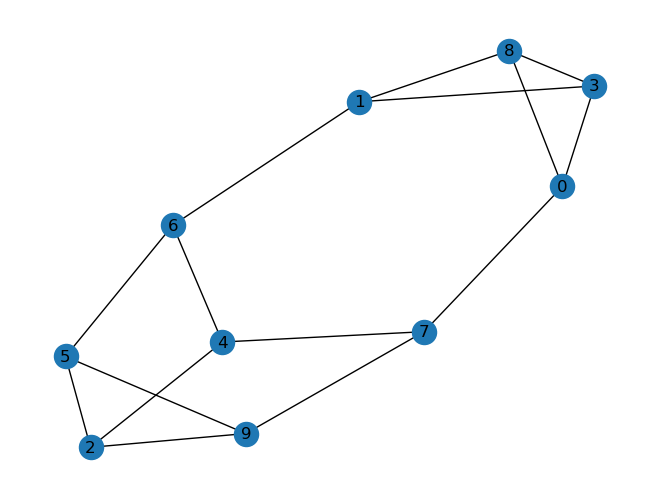

In [18]:
import matplotlib.pyplot as plt
seed = np.random.seed(42)
G = nx.random_regular_graph(3, 10, seed)
# Visualize the graph
nx.draw(G, with_labels=True)
plt.show()

In [20]:
import numpy as np
import networkx as nx
import matplotlib as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

# --- 1. Problem Setup ---
seed = np.random.seed(42)
G = nx.random_regular_graph(3, 10, seed)
n_qubits = G.number_of_nodes()
edges = G.edges()
num_edges = len(edges)

# Calculate Max Cut via Brute Force for the Ratio denominator
def get_max_cut(n, edges):
    max_c = 0
    for i in range(2**n):
        b = format(i, f'0{n}b')
        cut = sum(1 for u, v in edges if b[u] != b[v])
        if cut > max_c: max_c = cut
    return max_c

MAX_CUT_VAL = get_max_cut(n_qubits, edges)

# Define Cost Hamiltonian H_C = sum(ZiZj)
pauli_list = []
for i, j in edges:
    p_str = ["I"] * n_qubits
    p_str[n_qubits - 1 - i] = "Z"
    p_str[n_qubits - 1 - j] = "Z"
    pauli_list.append("".join(p_str))
cost_h = SparsePauliOp(pauli_list, coeffs=[1.0] * num_edges)

# --- 2. Adaptive Reflection Logic ---
def add_reflection(qc, state_vec, beta):
    n = qc.num_qubits
    v_gate = QuantumCircuit(n)
    v_gate.prepare_state(state_vec)
    
    # Unitary: V * (I - (1-e^-ib)|0><0|) * V_adj
    qc.append(v_gate.inverse(), range(n))
    qc.x(range(n))
    qc.mcp(-beta, list(range(n-1)), n-1)
    qc.x(range(n))
    qc.append(v_gate, range(n))

# --- 3. Iterative Optimization Loop ---
p_total = 10  # Number of iterative layers
estimator = StatevectorEstimator()
current_state = Statevector.from_label('+' * n_qubits)
ratios = []

print(f"{'Layer':<6} | {'Energy':<10} | {'Exp. Cut':<10} | {'Ratio (%)':<10}")
print("-" * 45)

for p in range(1, p_total + 1):
    
    def objective(params):
        gamma, beta = params
        qc = QuantumCircuit(n_qubits)
        qc.prepare_state(current_state)
        
        # Phase Separation (Cost)
        for i, j in edges:
            qc.rzz(2 * gamma, i, j)
            
        # Adaptive Mixing (Projector Mixer)
        add_reflection(qc, current_state, beta)
        
        pub = (qc, cost_h)
        return estimator.run([pub]).result()[0].data.evs

    # Layer-wise optimization
    res = minimize(objective, [0.5, 0.5], method='COBYLA')
    
    # --- Calculate Ratio ---
    # Expected Cut = 0.5 * (num_edges - <H_C>)
    expected_cut = 0.5 * (num_edges - res.fun)
    ratio = expected_cut / MAX_CUT_VAL
    ratios.append(ratio)
    
    # Update state for next layer
    final_qc = QuantumCircuit(n_qubits)
    final_qc.prepare_state(current_state)
    for i, j in edges:
        final_qc.rzz(2 * res.x[0], i, j)
    add_reflection(final_qc, current_state, res.x[1])
    current_state = Statevector.from_instruction(final_qc)
    
    print(f"{p:<6} | {res.fun:<10.4f} | {expected_cut:<10.4f} | {ratio*100:<10.2f}%")

print("-" * 45)
print(f"Final Approximation Ratio: {ratios[-1]:.4f}")

Layer  | Energy     | Exp. Cut   | Ratio (%) 
---------------------------------------------
1      | -2.9476    | 8.9738     | 69.03     %
2      | -4.6256    | 9.8128     | 75.48     %
3      | -5.7679    | 10.3840    | 79.88     %
4      | -7.9916    | 11.4958    | 88.43     %
5      | -9.0870    | 12.0435    | 92.64     %
6      | -10.0863   | 12.5432    | 96.49     %
7      | -10.2110   | 12.6055    | 96.97     %
8      | -10.2477   | 12.6239    | 97.11     %
9      | -10.2537   | 12.6268    | 97.13     %
10     | -10.2537   | 12.6269    | 97.13     %
---------------------------------------------
Final Approximation Ratio: 0.9713


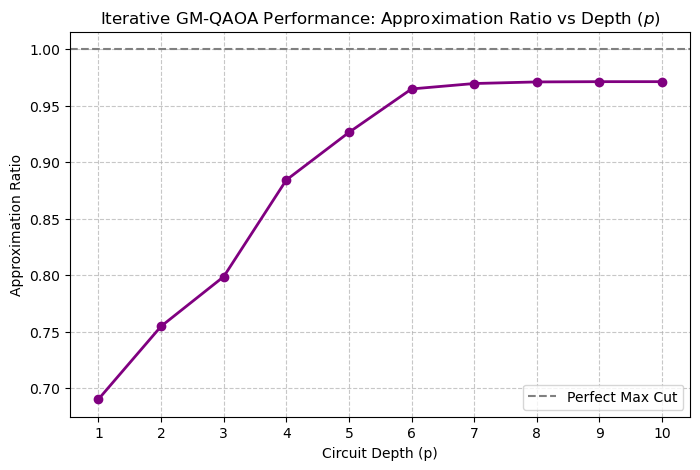

In [24]:
import matplotlib.pyplot as plt
depths = list(range(1,p_total+1))
plt.figure(figsize=(8, 5))
plt.plot(depths, ratios, 'o-', linewidth=2, color='purple')
plt.title('Iterative GM-QAOA Performance: Approximation Ratio vs Depth ($p$)')
plt.xlabel('Circuit Depth (p)')
plt.ylabel('Approximation Ratio')
plt.axhline(1.0, color='gray', linestyle='--', label='Perfect Max Cut')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(depths)
plt.show()